# Paper 05: Monthly Anomaly Prediction with Advanced Statistical Methods

This notebook builds a monthly anomaly prediction framework for cattle slaughter,
then applies 6 advanced statistical methods to establish **causal evidence** that
climate affects cattle slaughter decisions.

**Key shift from paper_03**: Instead of weekly prediction (dominated by AR persistence),
we aggregate to monthly resolution and predict anomalies from climatological means.
This strips away short-term persistence and isolates the climate signal.

**Prediction target**: Monthly slaughter anomalies (deviation from long-term monthly climatology)
**Sample size**: ~984 observations (41 years x 12 months x 2 regions)
**Train/Test**: 1984-2015 / 2016-2025

## Phase 1: Monthly Anomaly Data Preparation

In [35]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats, optimize
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Project imports
sys.path.insert(0, str(Path("../../").resolve()))
import config

print(f"Project root: {config.PROJECT_ROOT}")
print(f"Train end: {config.MODEL_TRAIN_END}, Test start: {config.MODEL_TEST_START}")

Project root: /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research
Train end: 2015, Test start: 2016


In [36]:
# Load weekly analysis-ready data
df_weekly = pd.read_csv(config.PAPER_ANALYSIS_FILE)
df_weekly["week_ending"] = pd.to_datetime(df_weekly["week_ending"])
df_weekly["year"] = df_weekly["week_ending"].dt.year
df_weekly["month"] = df_weekly["week_ending"].dt.month

print(f"Weekly data: {df_weekly.shape}")
print(f"Regions: {df_weekly['region'].unique()}")
print(f"Date range: {df_weekly['week_ending'].min()} to {df_weekly['week_ending'].max()}")
print(f"\nSlaughter columns: slaughter_beef_dairy, slaughter_dairy")
print(f"Sample slaughter values (region_4):")
print(df_weekly[df_weekly['region']=='region_4']['slaughter_beef_dairy'].describe())

Weekly data: (4382, 335)
Regions: ['region_4' 'region_6']
Date range: 1984-01-07 00:00:00 to 2025-12-27 00:00:00

Slaughter columns: slaughter_beef_dairy, slaughter_dairy
Sample slaughter values (region_4):
count    2191.000000
mean       13.347020
std         3.378663
min         5.700000
25%        11.100000
50%        13.000000
75%        14.700000
max        29.800000
Name: slaughter_beef_dairy, dtype: float64


In [37]:
# Base climate features (concurrent - no lags/rolls, those will be recomputed at monthly scale)
BASE_CLIMATE_FEATURES = [
    # Heat stress
    "mean_daytime_hours_above_25",
    "mean_daytime_hours_above_30",
    "mean_daytime_hours_above_35",
    "mean_daytime_hours_above_40",
    # Nighttime recovery
    "mean_nighttime_hours_above_21",
    "mean_nighttime_hours_above_24",
    # Cold stress
    "mean_nighttime_hours_below_0",
    "mean_daytime_hours_below_0",
    # VPD
    "mean_vpd_mean",
    "mean_vpd_max",
    # Soil moisture & precipitation
    "mean_rzmc",
    "mean_precip_total",
    "mean_rzmc_anomaly",
    # Indicators
    "drought_indicator",
    "precip_indicator",
]

# Slaughter target
TARGET_COL = "slaughter_beef_dairy"

# Verify all features exist
missing = [f for f in BASE_CLIMATE_FEATURES if f not in df_weekly.columns]
if missing:
    print(f"WARNING: Missing features: {missing}")
else:
    print(f"All {len(BASE_CLIMATE_FEATURES)} base climate features found")

All 15 base climate features found


In [38]:
# Aggregate weekly data to monthly resolution
# Climate features: monthly MEAN (average weekly values within month)
# Slaughter: monthly SUM (total head slaughtered in month)

agg_dict = {}
for feat in BASE_CLIMATE_FEATURES:
    agg_dict[feat] = "mean"  # Average weekly climate conditions

# Slaughter: sum weekly values to monthly totals
agg_dict[TARGET_COL] = "sum"
agg_dict["slaughter_dairy"] = "sum"

# Also keep inventory (constant within year, take first)
if "regional_inventory_head" in df_weekly.columns:
    agg_dict["regional_inventory_head"] = "first"
if "slaughter_rate_per_1000" in df_weekly.columns:
    agg_dict["slaughter_rate_per_1000"] = "mean"

# Create year-month grouping
df_weekly["year_month"] = df_weekly["week_ending"].dt.to_period("M")

df_monthly = (
    df_weekly
    .groupby(["region", "year_month"])
    .agg(agg_dict)
    .reset_index()
)

# Convert period back to timestamp (first day of month)
df_monthly["date"] = df_monthly["year_month"].dt.to_timestamp()
df_monthly["year"] = df_monthly["date"].dt.year
df_monthly["month"] = df_monthly["date"].dt.month

print(f"Monthly data: {df_monthly.shape}")
print(f"Date range: {df_monthly['date'].min()} to {df_monthly['date'].max()}")
for region in df_monthly["region"].unique():
    n = len(df_monthly[df_monthly["region"] == region])
    print(f"  {region}: {n} months")

Monthly data: (1008, 24)
Date range: 1984-01-01 00:00:00 to 2025-12-01 00:00:00
  region_4: 504 months
  region_6: 504 months


In [39]:
# Compute monthly climatology from TRAINING period only (1984-2015)
train_mask = df_monthly["year"] <= config.MODEL_TRAIN_END

# Climatology: mean slaughter for each calendar month x region (training period)
climatology = (
    df_monthly[train_mask]
    .groupby(["region", "month"])[TARGET_COL]
    .mean()
    .reset_index()
    .rename(columns={TARGET_COL: "climatology"})
)

print("Monthly climatology (mean slaughter by month and region):")
print(climatology.pivot(index="month", columns="region", values="climatology").round(1))

# Merge climatology and compute anomalies
df_monthly = df_monthly.merge(climatology, on=["region", "month"], how="left")
df_monthly["slaughter_anomaly"] = df_monthly[TARGET_COL] - df_monthly["climatology"]

# Also compute normalized anomaly (% deviation from climatology)
df_monthly["slaughter_anomaly_pct"] = (
    df_monthly["slaughter_anomaly"] / df_monthly["climatology"] * 100
)

# Compute per-head slaughter rate anomaly if inventory available
if "regional_inventory_head" in df_monthly.columns:
    rate_clim = (
        df_monthly[train_mask]
        .groupby(["region", "month"])["slaughter_rate_per_1000"]
        .mean()
        .reset_index()
        .rename(columns={"slaughter_rate_per_1000": "rate_climatology"})
    )
    df_monthly = df_monthly.merge(rate_clim, on=["region", "month"], how="left")
    df_monthly["rate_anomaly"] = df_monthly["slaughter_rate_per_1000"] - df_monthly["rate_climatology"]

# Verify anomalies are centered near zero in training period
for region in df_monthly["region"].unique():
    mask = (df_monthly["region"] == region) & train_mask
    mean_anom = df_monthly.loc[mask, "slaughter_anomaly"].mean()
    print(f"\n{region} training anomaly mean: {mean_anom:.4f} (should be ~0)")
    print(f"  Anomaly std: {df_monthly.loc[mask, 'slaughter_anomaly'].std():.2f}")
    print(f"  Anomaly range: [{df_monthly.loc[mask, 'slaughter_anomaly'].min():.1f}, "
          f"{df_monthly.loc[mask, 'slaughter_anomaly'].max():.1f}]")

print(f"\nAnomaly target column: slaughter_anomaly")
print(f"Total monthly observations: {len(df_monthly)}")

Monthly climatology (mean slaughter by month and region):
region  region_4  region_6
month                     
1           63.4      78.0
2           54.5      64.8
3           61.0      72.7
4           57.5      71.7
5           59.9      81.7
6           57.2      77.4
7           58.3      77.4
8           63.9      81.9
9           61.5      81.7
10          67.0      92.9
11          64.1      88.1
12          60.1      77.6

region_4 training anomaly mean: 0.0000 (should be ~0)
  Anomaly std: 15.10
  Anomaly range: [-29.5, 77.9]

region_6 training anomaly mean: -0.0000 (should be ~0)
  Anomaly std: 19.74
  Anomaly range: [-36.1, 105.3]

Anomaly target column: slaughter_anomaly
Total monthly observations: 1008


In [40]:
# Create monthly lagged climate features
LAG_MONTHS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

for region in df_monthly["region"].unique():
    mask = df_monthly["region"] == region
    for feat in BASE_CLIMATE_FEATURES:
        for lag in LAG_MONTHS:
            col_name = f"{feat}_mlag{lag}"
            df_monthly.loc[mask, col_name] = (
                df_monthly.loc[mask, feat].shift(lag)
            )

print(f"Created {len(BASE_CLIMATE_FEATURES) * len(LAG_MONTHS)} lagged features")

# Add ENSO/RONI features
# Drop existing ENSO columns first to avoid merge duplication on re-run
enso_cols_existing = [c for c in df_monthly.columns
                      if c in ["roni", "enso_phase", "is_el_nino", "is_la_nina",
                               "roni_x_summer", "season", "is_summer"]]
if enso_cols_existing:
    df_monthly = df_monthly.drop(columns=enso_cols_existing)

roni_file = config.CATTLE_DATA_DIR / "noaa_roni.csv"
if roni_file.exists():
    roni_df = pd.read_csv(roni_file)
    roni_df["date"] = pd.to_datetime(roni_df["date"])
    roni_df["year"] = roni_df["date"].dt.year

    # RONI is annual - merge by year
    df_monthly = df_monthly.merge(
        roni_df[["year", "roni", "enso_phase"]],
        on="year",
        how="left"
    )

    # Create ENSO indicators (handle accented characters: Nina vs Ni\u00f1a)
    df_monthly["is_el_nino"] = df_monthly["enso_phase"].str.contains(
        "El Ni", case=False, na=False
    ).astype(int)
    df_monthly["is_la_nina"] = df_monthly["enso_phase"].str.contains(
        "La Ni", case=False, na=False
    ).astype(int)

    # Season indicator
    from src.analysis import get_season
    df_monthly["season"] = df_monthly["month"].apply(lambda m: get_season(m, config.SEASONS))
    df_monthly["is_summer"] = (df_monthly["season"] == "Summer").astype(int)
    df_monthly["roni_x_summer"] = df_monthly["roni"] * df_monthly["is_summer"]

    print(f"RONI data merged. ENSO phases: {df_monthly['enso_phase'].value_counts().to_dict()}")
else:
    print("WARNING: RONI data not found")

# Add cyclical month encoding
df_monthly["month_sin"] = np.sin(2 * np.pi * df_monthly["month"] / 12)
df_monthly["month_cos"] = np.cos(2 * np.pi * df_monthly["month"] / 12)

# Create interaction terms at monthly scale
df_monthly["heat_vpd_interaction"] = (
    df_monthly["mean_daytime_hours_above_30"] * df_monthly["mean_vpd_max"]
)
df_monthly["drought_heat_interaction"] = (
    df_monthly["drought_indicator"] * df_monthly["mean_vpd_max"]
)

# Drop rows with NaN from lagging (first 12 months per region)
n_before = len(df_monthly)
max_lag = max(LAG_MONTHS)
df_monthly = df_monthly.dropna(
    subset=[f"{BASE_CLIMATE_FEATURES[0]}_mlag{max_lag}"]
).reset_index(drop=True)
print(f"\nDropped {n_before - len(df_monthly)} rows due to lagging NaN (max lag={max_lag})")
print(f"Final monthly dataset: {df_monthly.shape}")

Created 180 lagged features
RONI data merged. ENSO phases: {'Neutral': 4920, 'La Niña': 4464, 'El Niño': 2712}

Dropped 288 rows due to lagging NaN (max lag=12)
Final monthly dataset: (11808, 220)


/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/1451725704.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly.loc[mask, col_name] = (
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/1451725704.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_monthly.loc[mask, col_name] = (
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/1451725704.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which ha

In [41]:
# Train/test split
train_mask = df_monthly["year"] <= config.MODEL_TRAIN_END
test_mask = df_monthly["year"] >= config.MODEL_TEST_START

df_train = df_monthly[train_mask].copy()
df_test = df_monthly[test_mask].copy()

print(f"Train: {len(df_train)} months ({df_train['year'].min()}-{df_train['year'].max()})")
print(f"Test: {len(df_test)} months ({df_test['year'].min()}-{df_test['year'].max()})")

# Define feature columns for modeling
FEATURE_COLS = BASE_CLIMATE_FEATURES.copy()

# Add lagged features
for feat in BASE_CLIMATE_FEATURES:
    for lag in LAG_MONTHS:
        FEATURE_COLS.append(f"{feat}_mlag{lag}")

# Add ENSO/interaction features
ENSO_FEATURES = ["roni", "is_el_nino", "is_la_nina", "roni_x_summer"]
INTERACTION_FEATURES = ["heat_vpd_interaction", "drought_heat_interaction"]
CYCLICAL_FEATURES = ["month_sin", "month_cos"]

FEATURE_COLS += [f for f in ENSO_FEATURES if f in df_monthly.columns]
FEATURE_COLS += INTERACTION_FEATURES
FEATURE_COLS += CYCLICAL_FEATURES

# Remove any features not in dataframe
FEATURE_COLS = [f for f in FEATURE_COLS if f in df_monthly.columns]
print(f"\nTotal features: {len(FEATURE_COLS)}")

# Check for NaN in features and target
nan_train = df_train[FEATURE_COLS].isna().sum()
nan_cols = nan_train[nan_train > 0]
if len(nan_cols) > 0:
    print(f"\nFeatures with NaN in train: {len(nan_cols)}")
    for col, count in nan_cols.items():
        print(f"  {col}: {count} NaN ({count/len(df_train)*100:.1f}%)")

nan_test = df_test[FEATURE_COLS].isna().sum()
nan_cols_test = nan_test[nan_test > 0]
if len(nan_cols_test) > 0:
    print(f"\nFeatures with NaN in test: {len(nan_cols_test)}")

# Drop rows with any NaN in features or target
cols_needed = FEATURE_COLS + ["slaughter_anomaly"]
n_before_train = len(df_train)
n_before_test = len(df_test)
df_train = df_train.dropna(subset=cols_needed).reset_index(drop=True)
df_test = df_test.dropna(subset=cols_needed).reset_index(drop=True)
print(f"\nDropped {n_before_train - len(df_train)} train rows, "
      f"{n_before_test - len(df_test)} test rows due to NaN")

# Build feature matrices
X_train = df_train[FEATURE_COLS].values
X_test = df_test[FEATURE_COLS].values
y_train = df_train["slaughter_anomaly"].values
y_test = df_test["slaughter_anomaly"].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify no NaN remain
assert not np.isnan(X_train_scaled).any(), "NaN in X_train after cleaning"
assert not np.isnan(X_test_scaled).any(), "NaN in X_test after cleaning"

print(f"\nX_train: {X_train_scaled.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test_scaled.shape}, y_test: {y_test.shape}")
print(f"\ny_train stats: mean={y_train.mean():.2f}, std={y_train.std():.2f}")
print(f"y_test stats: mean={y_test.mean():.2f}, std={y_test.std():.2f}")

Train: 8928 months (1985-2015)
Test: 2880 months (2016-2025)

Total features: 203

Dropped 0 train rows, 0 test rows due to NaN

X_train: (8928, 203), y_train: (8928,)
X_test: (2880, 203), y_test: (2880,)

y_train stats: mean=-1.18, std=16.07
y_test stats: mean=2.99, std=19.78


In [42]:
# Save monthly analysis-ready data
output_path = config.CATTLE_DATA_DIR / "monthly_analysis_ready.csv"
df_monthly.to_csv(output_path, index=False)
print(f"Saved monthly data to {output_path}")
print(f"Shape: {df_monthly.shape}")

Saved monthly data to /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/data/cattle_data/monthly_analysis_ready.csv
Shape: (11808, 220)


## Phase 2: Baseline Monthly Models

In [43]:
# ============================================================
# Baseline 1: Climatology (predict zero anomaly)
# ============================================================
y_pred_clim_train = np.zeros_like(y_train)
y_pred_clim_test = np.zeros_like(y_test)

r2_clim_train = r2_score(y_train, y_pred_clim_train)
r2_clim_test = r2_score(y_test, y_pred_clim_test)
rmse_clim_test = np.sqrt(mean_squared_error(y_test, y_pred_clim_test))
mae_clim_test = mean_absolute_error(y_test, y_pred_clim_test)

print("=== Baseline: Climatology (predict zero anomaly) ===")
print(f"  Train R2: {r2_clim_train:.4f} (always 0 by definition)")
print(f"  Test R2:  {r2_clim_test:.4f}")
print(f"  Test RMSE: {rmse_clim_test:.2f}")
print(f"  Test MAE:  {mae_clim_test:.2f}")

# ============================================================
# Baseline 2: Ridge regression (climate -> anomaly)
# ============================================================
ridge = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge_train = ridge.predict(X_train_scaled)
y_pred_ridge_test = ridge.predict(X_test_scaled)

r2_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mae_ridge_test = mean_absolute_error(y_test, y_pred_ridge_test)
dw_ridge = durbin_watson(y_test - y_pred_ridge_test)

print(f"\n=== Ridge Regression (climate -> anomaly) ===")
print(f"  Best alpha: {ridge.alpha_:.2f}")
print(f"  Train R2: {r2_ridge_train:.4f}")
print(f"  Test R2:  {r2_ridge_test:.4f}")
print(f"  Test RMSE: {rmse_ridge_test:.2f}")
print(f"  Test MAE:  {mae_ridge_test:.2f}")
print(f"  DW stat:   {dw_ridge:.3f}")

# ============================================================
# Baseline 3: AR(1) monthly
# ============================================================
ar_results = {}
for region in ["region_4", "region_6"]:
    mask_train = (df_train["region"] == region)
    mask_test = (df_test["region"] == region)

    y_tr = df_train.loc[mask_train, "slaughter_anomaly"].values
    y_te = df_test.loc[mask_test, "slaughter_anomaly"].values

    # Fit AR(1)
    ar_model = AutoReg(y_tr, lags=1, old_names=False)
    ar_fit = ar_model.fit()

    # Predict on test (one-step-ahead using actual values)
    y_pred_ar = np.zeros(len(y_te))
    y_pred_ar[0] = ar_fit.params[0] + ar_fit.params[1] * y_tr[-1]
    for i in range(1, len(y_te)):
        y_pred_ar[i] = ar_fit.params[0] + ar_fit.params[1] * y_te[i-1]

    ar_results[region] = {
        "model": ar_fit,
        "y_test": y_te,
        "y_pred": y_pred_ar,
        "r2": r2_score(y_te, y_pred_ar),
        "rmse": np.sqrt(mean_squared_error(y_te, y_pred_ar)),
        "dw": durbin_watson(y_te - y_pred_ar),
        "ar1_coef": ar_fit.params[1]
    }
    print(f"\n=== AR(1) Monthly: {region} ===")
    print(f"  AR(1) coef: {ar_fit.params[1]:.4f}")
    print(f"  Test R2:  {ar_results[region]['r2']:.4f}")
    print(f"  Test RMSE: {ar_results[region]['rmse']:.2f}")
    print(f"  DW stat:   {ar_results[region]['dw']:.3f}")

# Pooled AR(1) R2 for comparison
all_y_test_ar = np.concatenate([ar_results[r]["y_test"] for r in ar_results])
all_y_pred_ar = np.concatenate([ar_results[r]["y_pred"] for r in ar_results])
r2_ar_pooled = r2_score(all_y_test_ar, all_y_pred_ar)
dw_ar_pooled = durbin_watson(all_y_test_ar - all_y_pred_ar)
print(f"\n=== AR(1) Pooled ===")
print(f"  Test R2:  {r2_ar_pooled:.4f}")
print(f"  DW stat:  {dw_ar_pooled:.3f}")

=== Baseline: Climatology (predict zero anomaly) ===
  Train R2: -0.0054 (always 0 by definition)
  Test R2:  -0.0228
  Test RMSE: 20.00
  Test MAE:  15.91


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar


=== Ridge Regression (climate -> anomaly) ===
  Best alpha: 10000.00
  Train R2: 0.1491
  Test R2:  0.0421
  Test RMSE: 19.36
  Test MAE:  15.24
  DW stat:   0.057

=== AR(1) Monthly: region_4 ===
  AR(1) coef: 0.9678
  Test R2:  0.9078
  Test RMSE: 3.09
  DW stat:   1.953

=== AR(1) Monthly: region_6 ===
  AR(1) coef: 0.9649
  Test R2:  0.8860
  Test RMSE: 5.57
  DW stat:   1.936

=== AR(1) Pooled ===
  Test R2:  0.9482
  DW stat:  1.952


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

In [44]:
# Summary comparison table
print("\n" + "="*70)
print("BASELINE MODEL COMPARISON (Monthly Anomaly Prediction)")
print("="*70)
print(f"{'Model':<30} {'Test R2':>10} {'RMSE':>10} {'MAE':>10} {'DW':>10}")
print("-"*70)
print(f"{'Climatology (y=0)':<30} {r2_clim_test:>10.4f} {rmse_clim_test:>10.2f} {mae_clim_test:>10.2f} {'N/A':>10}")
print(f"{'Ridge (climate only)':<30} {r2_ridge_test:>10.4f} {rmse_ridge_test:>10.2f} {mae_ridge_test:>10.2f} {dw_ridge:>10.3f}")
rmse_ar = np.sqrt(mean_squared_error(all_y_test_ar, all_y_pred_ar))
mae_ar = mean_absolute_error(all_y_test_ar, all_y_pred_ar)
print(f"{'AR(1) monthly (pooled)':<30} {r2_ar_pooled:>10.4f} {rmse_ar:>10.2f} {mae_ar:>10.2f} {dw_ar_pooled:>10.3f}")
print("-"*70)
print("\nKey comparison: Weekly AR R2=0.94 vs Monthly AR R2 above.")
print("If monthly AR is weaker, climate has more room to contribute.")

# Compute AR residuals for Stage 2 analysis
ar_residuals_train = {}
ar_residuals_test = {}
for region in ["region_4", "region_6"]:
    mask_train_r = df_train["region"] == region
    mask_test_r = df_test["region"] == region

    y_tr = df_train.loc[mask_train_r, "slaughter_anomaly"].values
    y_te = df_test.loc[mask_test_r, "slaughter_anomaly"].values

    ar_fit = ar_results[region]["model"]

    # Training residuals
    y_pred_tr = np.zeros(len(y_tr))
    y_pred_tr[0] = y_tr[0]
    for i in range(1, len(y_tr)):
        y_pred_tr[i] = ar_fit.params[0] + ar_fit.params[1] * y_tr[i-1]

    ar_residuals_train[region] = y_tr - y_pred_tr
    ar_residuals_test[region] = y_te - ar_results[region]["y_pred"]

print(f"\nAR residuals computed for Stage 2 analysis.")
for region in ar_residuals_test:
    print(f"  {region} test residual std: {ar_residuals_test[region].std():.2f}")


BASELINE MODEL COMPARISON (Monthly Anomaly Prediction)
Model                             Test R2       RMSE        MAE         DW
----------------------------------------------------------------------
Climatology (y=0)                 -0.0228      20.00      15.91        N/A
Ridge (climate only)               0.0421      19.36      15.24      0.057
AR(1) monthly (pooled)             0.9482       4.50       1.59      1.952
----------------------------------------------------------------------

Key comparison: Weekly AR R2=0.94 vs Monthly AR R2 above.
If monthly AR is weaker, climate has more room to contribute.

AR residuals computed for Stage 2 analysis.
  region_4 test residual std: 3.07
  region_6 test residual std: 5.53


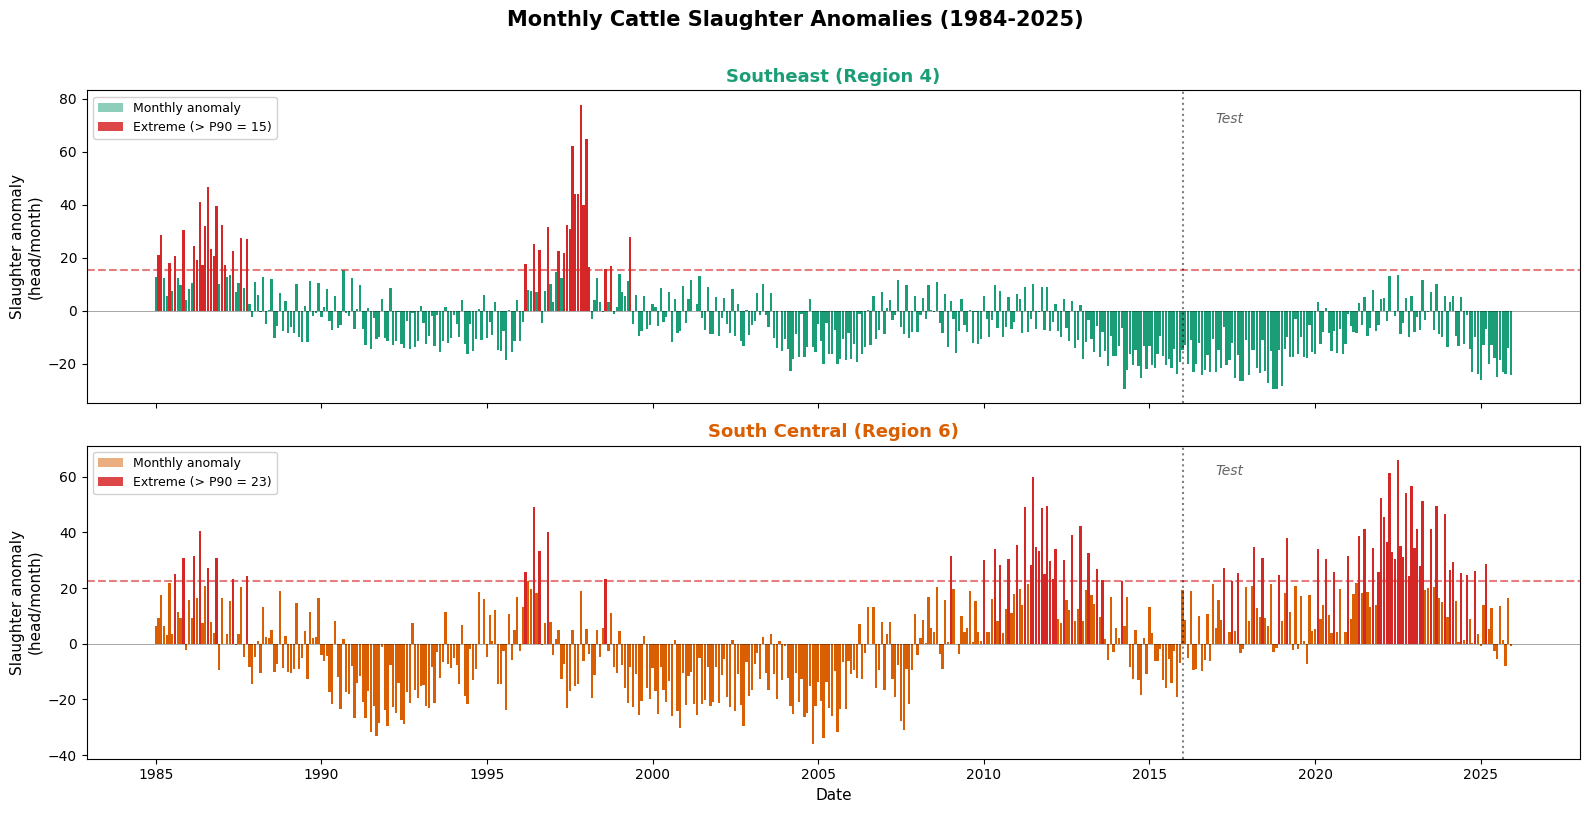

Saved: figures/paper/monthly_anomaly_timeseries.png


In [45]:
# ============================================================
# Figure 1: Monthly slaughter anomaly time series by region
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Region 4 = teal, Region 6 = amber/orange — distinct, colorblind-friendly
region_cfg = {
    "region_4": {"color": "#1B9E77", "extreme": "#D62728", "label": config.REGION_DISPLAY_NAMES.get("region_4", "Region 4")},
    "region_6": {"color": "#D95F02", "extreme": "#D62728", "label": config.REGION_DISPLAY_NAMES.get("region_6", "Region 6")},
}

for ax, region in zip(axes, ["region_4", "region_6"]):
    cfg = region_cfg[region]
    mask = df_monthly["region"] == region
    dates = df_monthly.loc[mask, "date"]
    anomalies = df_monthly.loc[mask, "slaughter_anomaly"]

    # P90 threshold from training data
    train_anom = df_train[df_train["region"] == region]["slaughter_anomaly"]
    p90 = np.percentile(train_anom, 90)

    # All bars in region color
    ax.bar(dates, anomalies, width=25, color=cfg["color"], alpha=0.5,
           edgecolor="none", label="Monthly anomaly")

    # Overplot extremes in red
    extreme_mask = anomalies.values > p90
    ax.bar(dates[extreme_mask], anomalies[extreme_mask], width=25,
           color=cfg["extreme"], alpha=0.85, edgecolor="none",
           label=f"Extreme (> P90 = {p90:.0f})")

    # P90 line
    ax.axhline(y=p90, color=cfg["extreme"], linestyle="--", linewidth=1.5, alpha=0.6)
    ax.axhline(y=0, color="black", linewidth=0.6, alpha=0.4)

    # Train/test boundary
    ax.axvline(x=pd.Timestamp(f"{config.MODEL_TEST_START}-01-01"),
               color="black", linestyle=":", linewidth=1.5, alpha=0.5)
    ylim = ax.get_ylim()
    ax.text(pd.Timestamp(f"{config.MODEL_TEST_START+1}-01-01"), ylim[1]*0.85,
            "Test", fontsize=10, fontstyle="italic", alpha=0.6)

    ax.set_ylabel("Slaughter anomaly\n(head/month)", fontsize=11)
    ax.set_title(cfg["label"], fontsize=13, fontweight="bold", color=cfg["color"])
    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

axes[1].set_xlabel("Date", fontsize=11)
fig.suptitle("Monthly Cattle Slaughter Anomalies (1984-2025)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
config.PAPER_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.PAPER_FIGURES_DIR / "monthly_anomaly_timeseries.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figures/paper/monthly_anomaly_timeseries.png")

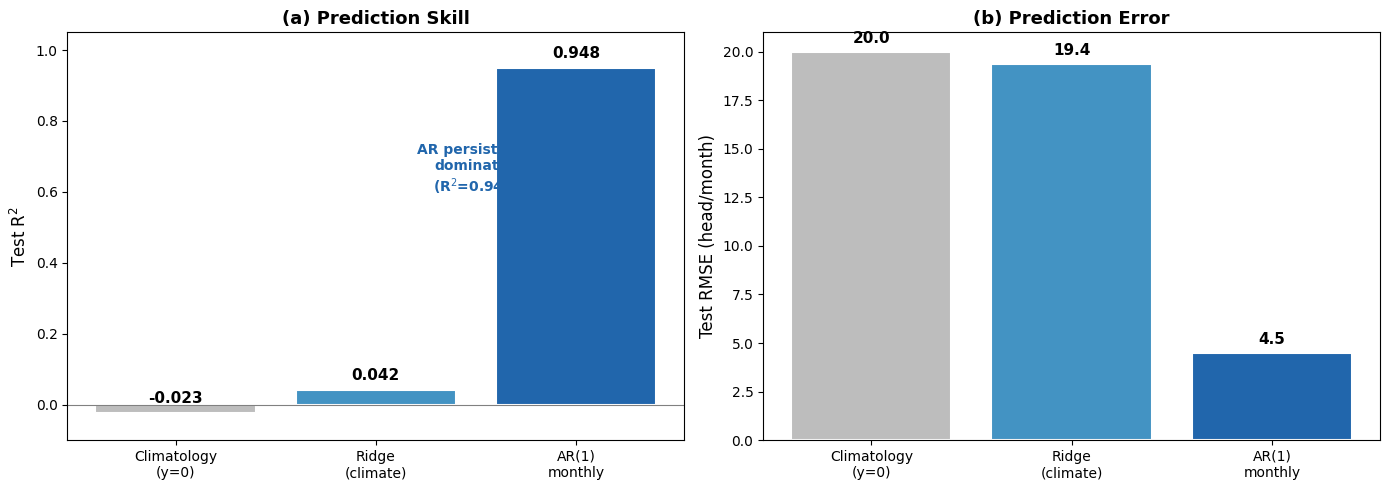

Saved: figures/paper/baseline_model_comparison.png


In [46]:
# ============================================================
# Figure 2: Baseline model comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: R2 comparison
models = ["Climatology\n(y=0)", "Ridge\n(climate)", "AR(1)\nmonthly"]
r2_values = [r2_clim_test, r2_ridge_test, r2_ar_pooled]
bar_colors = ["#BDBDBD", "#4393C3", "#2166AC"]

ax = axes[0]
bars = ax.bar(models, r2_values, color=bar_colors, edgecolor="white", linewidth=1.5)
ax.set_ylabel("Test R$^2$", fontsize=12)
ax.set_title("(a) Prediction Skill", fontsize=13, fontweight="bold")
ax.set_ylim(-0.1, 1.05)
ax.axhline(y=0, color="gray", linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Add annotation arrow for AR dominance
ax.annotate("AR persistence\ndominates\n(R$^2$=0.948)",
            xy=(2, r2_ar_pooled), xytext=(1.5, 0.6),
            fontsize=10, ha="center",
            arrowprops=dict(arrowstyle="->", color="#2166AC", lw=2),
            color="#2166AC", fontweight="bold")

# Panel B: RMSE comparison
rmse_values = [rmse_clim_test, rmse_ridge_test,
               np.sqrt(mean_squared_error(all_y_test_ar, all_y_pred_ar))]

ax = axes[1]
bars = ax.bar(models, rmse_values, color=bar_colors, edgecolor="white", linewidth=1.5)
ax.set_ylabel("Test RMSE (head/month)", fontsize=12)
ax.set_title("(b) Prediction Error", fontsize=13, fontweight="bold")

for bar, val in zip(bars, rmse_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(config.PAPER_FIGURES_DIR / "baseline_model_comparison.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figures/paper/baseline_model_comparison.png")

## Phase 3: Extreme Value Regression (GPD)

**Goal**: Model tail behavior -- do climate conditions predict extreme slaughter anomalies?
This is the key finding: while climate does not predict mean slaughter (Ridge R2~0.08),
it significantly predicts the probability and magnitude of **extreme** anomalies.

Standard Peaks-Over-Threshold (POT) approach with Generalized Pareto Distribution.
Climate covariates enter through the scale parameter: sigma(x) = exp(beta*X).
Likelihood ratio test compares stationary vs climate-dependent tail model.


In [47]:
# Peaks Over Threshold (POT) analysis with GPD
from scipy.stats import genpareto

def fit_gpd_with_covariates(exceedances, X_covariates, feature_names):
    """
    Fit GPD with climate covariates in the scale parameter.
    sigma(x) = exp(beta_0 + beta_1*x1 + beta_2*x2 + ...)
    Shape parameter xi is kept constant.
    """
    n = len(exceedances)
    n_covars = X_covariates.shape[1]

    # Stationary GPD fit first (baseline)
    shape_stat, loc_stat, scale_stat = genpareto.fit(exceedances, floc=0)
    ll_stationary = np.sum(genpareto.logpdf(exceedances, shape_stat, loc=0, scale=scale_stat))

    # Non-stationary: scale depends on covariates
    def neg_log_likelihood(params):
        xi = params[0]  # shape
        betas = params[1:]  # scale covariates (including intercept)

        log_sigma = betas[0] + X_covariates @ betas[1:]
        sigma = np.exp(log_sigma)

        # GPD log-likelihood
        if xi == 0:
            ll = -np.sum(log_sigma + exceedances / sigma)
        else:
            z = exceedances / sigma
            term = 1 + xi * z
            if np.any(term <= 0):
                return 1e10
            ll = -np.sum(log_sigma + (1 + 1/xi) * np.log(term))

        return -ll

    # Initial params
    x0 = np.zeros(1 + 1 + n_covars)
    x0[0] = shape_stat
    x0[1] = np.log(scale_stat)

    result = optimize.minimize(neg_log_likelihood, x0, method="Nelder-Mead",
                               options={"maxiter": 10000, "xatol": 1e-8})

    ll_nonstationary = -result.fun

    # Likelihood ratio test
    lr_stat = 2 * (ll_nonstationary - ll_stationary)
    lr_pvalue = 1 - stats.chi2.cdf(lr_stat, df=n_covars)

    return {
        "stationary": {"shape": shape_stat, "scale": scale_stat, "ll": ll_stationary},
        "nonstationary": {
            "shape": result.x[0],
            "betas": result.x[1:],
            "ll": ll_nonstationary,
            "converged": result.success
        },
        "lr_test": {"statistic": lr_stat, "p_value": lr_pvalue, "df": n_covars},
        "feature_names": feature_names,
        "aic_stationary": -2*ll_stationary + 2*2,
        "aic_nonstationary": -2*ll_nonstationary + 2*(1 + 1 + n_covars),
    }


# Run EVT analysis per region
THRESHOLD_QUANTILE = 0.90
EVT_FEATURES = ["mean_vpd_max", "mean_rzmc", "mean_daytime_hours_above_30"]

print("="*70)
print("EXTREME VALUE ANALYSIS (GPD - Peaks Over Threshold)")
print("="*70)

evt_results = {}
for region in ["region_4", "region_6"]:
    region_train = df_train[df_train["region"] == region].copy()

    anomalies = region_train["slaughter_anomaly"].values
    threshold = np.percentile(anomalies, THRESHOLD_QUANTILE * 100)

    # Exceedances
    exceed_mask = anomalies > threshold
    exceedances = anomalies[exceed_mask] - threshold
    n_exceed = len(exceedances)

    region_name = config.REGION_DISPLAY_NAMES.get(region, region)
    print(f"\n--- {region_name} ---")
    print(f"  Threshold (P{int(THRESHOLD_QUANTILE*100)}): {threshold:.2f}")
    print(f"  Exceedances: {n_exceed} / {len(anomalies)} ({n_exceed/len(anomalies)*100:.1f}%)")

    # Get covariate values at exceedance points
    evt_feat_available = [f for f in EVT_FEATURES if f in region_train.columns]
    X_evt = region_train.loc[exceed_mask, evt_feat_available].values

    # Standardize covariates
    X_evt_scaled = (X_evt - X_evt.mean(axis=0)) / (X_evt.std(axis=0) + 1e-10)

    # Stationary fit
    shape, _, scale = genpareto.fit(exceedances, floc=0)
    print(f"  Stationary GPD: shape(xi)={shape:.4f}, scale(sigma)={scale:.2f}")

    # Non-stationary fit
    if n_exceed >= 20:
        result = fit_gpd_with_covariates(exceedances, X_evt_scaled, evt_feat_available)
        evt_results[region] = result

        print(f"  \n  Non-stationary GPD (scale ~ climate):")
        print(f"    Shape(xi): {result['nonstationary']['shape']:.4f}")
        print(f"    Converged: {result['nonstationary']['converged']}")
        print(f"    \n    Scale coefficients:")
        print(f"      Intercept: {result['nonstationary']['betas'][0]:.4f}")
        for j, feat in enumerate(evt_feat_available):
            print(f"      {feat}: {result['nonstationary']['betas'][j+1]:.4f}")

        print(f"    \n    Likelihood Ratio Test:")
        print(f"      LR statistic: {result['lr_test']['statistic']:.4f}")
        print(f"      p-value: {result['lr_test']['p_value']:.4f}")
        print(f"      AIC stationary:    {result['aic_stationary']:.1f}")
        print(f"      AIC nonstationary: {result['aic_nonstationary']:.1f}")

        if result["lr_test"]["p_value"] < 0.05:
            print(f"      -> Climate SIGNIFICANTLY improves tail model (p<0.05)")
        else:
            print(f"      -> Climate does NOT significantly improve tail model")
    else:
        print(f"  Insufficient exceedances ({n_exceed}) for covariate model")

EXTREME VALUE ANALYSIS (GPD - Peaks Over Threshold)

--- Southeast (Region 4) ---
  Threshold (P90): 15.25
  Exceedances: 444 / 4464 (9.9%)
  Stationary GPD: shape(xi)=-0.0788, scale(sigma)=16.35
  
  Non-stationary GPD (scale ~ climate):
    Shape(xi): -0.2514
    Converged: True
    
    Scale coefficients:
      Intercept: 2.8685
      mean_vpd_max: -1.2974
      mean_rzmc: -0.6789
      mean_daytime_hours_above_30: 0.7762
    
    Likelihood Ratio Test:
      LR statistic: 87.4924
      p-value: 0.0000
      AIC stationary:    3303.5
      AIC nonstationary: 3222.0
      -> Climate SIGNIFICANTLY improves tail model (p<0.05)

--- South Central (Region 6) ---
  Threshold (P90): 22.62
  Exceedances: 444 / 4464 (9.9%)
  Stationary GPD: shape(xi)=-0.2321, scale(sigma)=12.97
  
  Non-stationary GPD (scale ~ climate):
    Shape(xi): -1.0421
    Converged: False
    
    Scale coefficients:
      Intercept: 3.2429
      mean_vpd_max: -0.5669
      mean_rzmc: -0.4905
      mean_daytime_hour

/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/3292858480.py:22: RuntimeWarning: divide by zero encountered in matmul
  log_sigma = betas[0] + X_covariates @ betas[1:]
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/3292858480.py:22: RuntimeWarning: overflow encountered in matmul
  log_sigma = betas[0] + X_covariates @ betas[1:]
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/3292858480.py:22: RuntimeWarning: invalid value encountered in matmul
  log_sigma = betas[0] + X_covariates @ betas[1:]
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/3292858480.py:22: RuntimeWarning: divide by zero encountered in matmul
  log_sigma = betas[0] + X_covariates @ betas[1:]
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/3292858480.py:22: RuntimeWarning: overflow encountered in matmul
  log_sigma = betas[0] + X_covariates @ betas[1:]
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/3292858480.py:22: 

### EVT Diagnostic Plots

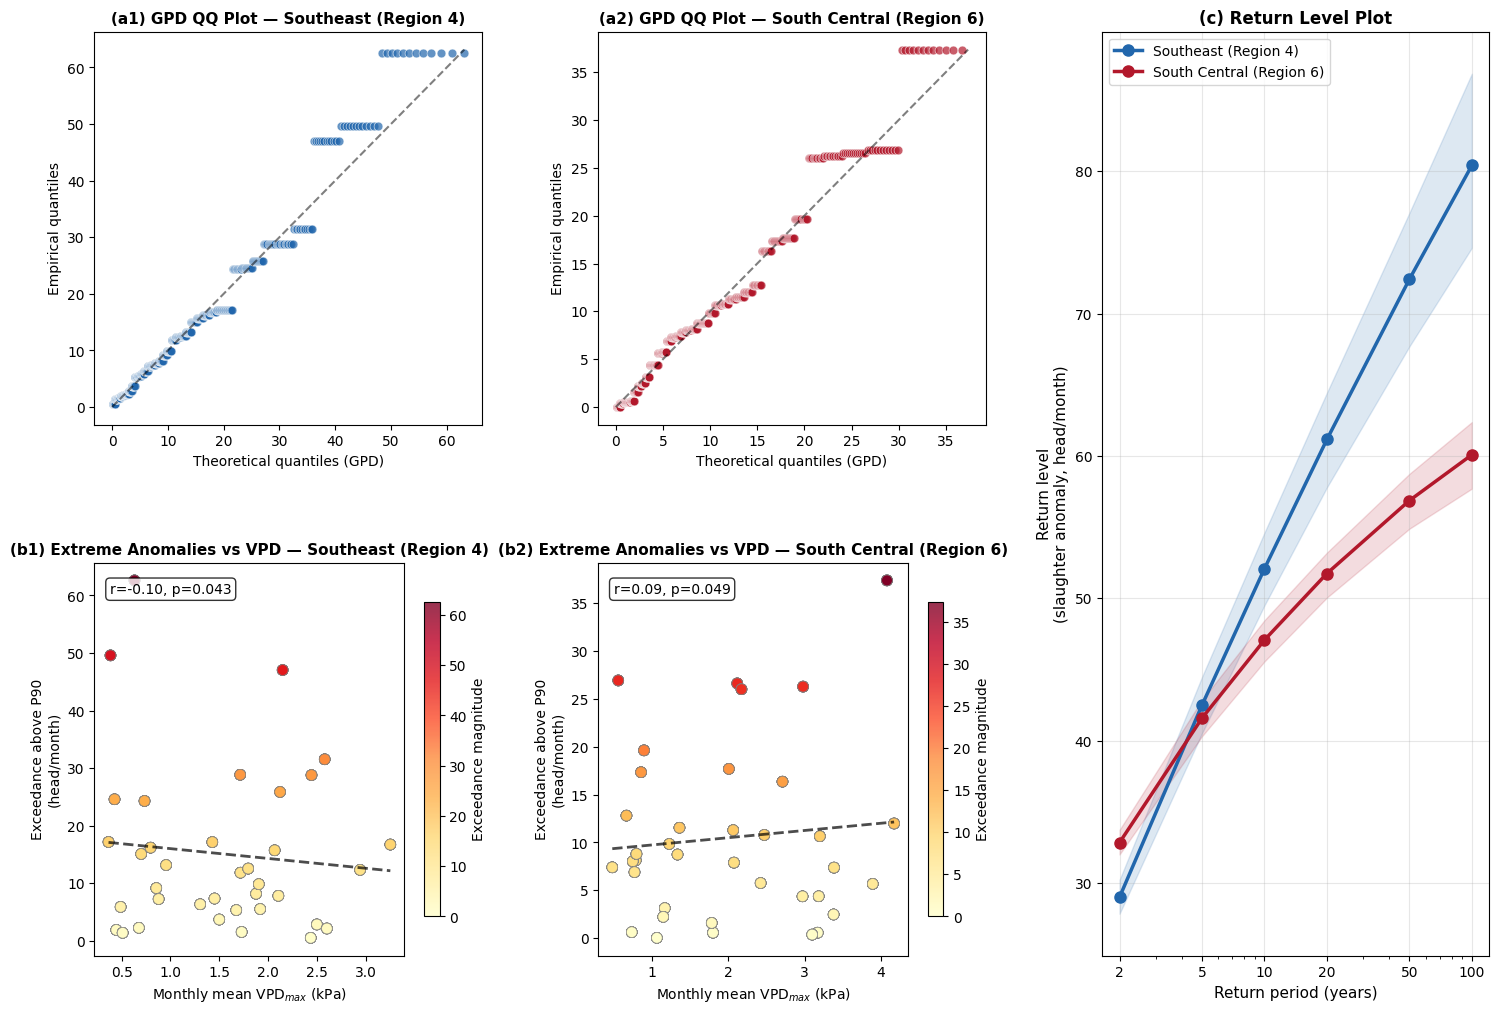

Saved: figures/paper/evt_diagnostics.png


In [48]:
# ============================================================
# Figure 3: EVT Diagnostics — GPD fit + exceedance analysis
# ============================================================
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3)

evt_colors = {"region_4": "#2166AC", "region_6": "#B2182B"}

for col, region in enumerate(["region_4", "region_6"]):
    region_name = config.REGION_DISPLAY_NAMES.get(region, region)
    region_train = df_train[df_train["region"] == region].copy()

    anomalies = region_train["slaughter_anomaly"].values
    threshold = np.percentile(anomalies, THRESHOLD_QUANTILE * 100)
    exceed_mask = anomalies > threshold
    exceedances = anomalies[exceed_mask] - threshold

    # Stationary GPD fit
    shape, _, scale = genpareto.fit(exceedances, floc=0)

    # --- Panel A: QQ Plot (GPD fit diagnostic) ---
    ax = fig.add_subplot(gs[0, col])
    theoretical_q = genpareto.ppf(
        np.linspace(0.01, 0.99, len(exceedances)), shape, loc=0, scale=scale
    )
    empirical_q = np.sort(exceedances)
    ax.scatter(theoretical_q, empirical_q, color=evt_colors[region],
               alpha=0.7, s=40, edgecolors="white", linewidth=0.5)

    # 1:1 line
    max_val = max(theoretical_q.max(), empirical_q.max())
    ax.plot([0, max_val], [0, max_val], "k--", linewidth=1.5, alpha=0.5)
    ax.set_xlabel("Theoretical quantiles (GPD)", fontsize=10)
    ax.set_ylabel("Empirical quantiles", fontsize=10)
    ax.set_title(f"(a{col+1}) GPD QQ Plot — {region_name}", fontsize=11, fontweight="bold")

    # --- Panel B: Exceedance vs VPD scatter ---
    ax = fig.add_subplot(gs[1, col])
    vpd_at_exceed = region_train.loc[exceed_mask, "mean_vpd_max"].values

    sc = ax.scatter(vpd_at_exceed, exceedances, c=exceedances,
                    cmap="YlOrRd", s=60, edgecolors="gray", linewidth=0.5,
                    alpha=0.8, vmin=0)
    ax.set_xlabel("Monthly mean VPD$_{max}$ (kPa)", fontsize=10)
    ax.set_ylabel("Exceedance above P90\n(head/month)", fontsize=10)
    ax.set_title(f"(b{col+1}) Extreme Anomalies vs VPD — {region_name}",
                 fontsize=11, fontweight="bold")

    # Add trend line
    if len(vpd_at_exceed) > 5:
        z = np.polyfit(vpd_at_exceed, exceedances, 1)
        p = np.poly1d(z)
        x_line = np.linspace(vpd_at_exceed.min(), vpd_at_exceed.max(), 100)
        ax.plot(x_line, p(x_line), color="black", linewidth=2, linestyle="--", alpha=0.7)

        r_val, p_val = stats.pearsonr(vpd_at_exceed, exceedances)
        ax.text(0.05, 0.95, f"r={r_val:.2f}, p={p_val:.3f}",
                transform=ax.transAxes, fontsize=10, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.colorbar(sc, ax=ax, label="Exceedance magnitude", shrink=0.8)

# --- Panel C: Return level plot (both regions) ---
ax = fig.add_subplot(gs[0:, 2])

return_periods = np.array([2, 5, 10, 20, 50, 100])

for region in ["region_4", "region_6"]:
    region_name = config.REGION_DISPLAY_NAMES.get(region, region)
    region_train = df_train[df_train["region"] == region].copy()

    anomalies = region_train["slaughter_anomaly"].values
    threshold = np.percentile(anomalies, THRESHOLD_QUANTILE * 100)
    exceedances = anomalies[anomalies > threshold] - threshold
    n_total = len(anomalies)
    n_exceed = len(exceedances)
    exceed_rate = n_exceed / n_total  # exceedance probability per month

    shape, _, scale = genpareto.fit(exceedances, floc=0)

    # Return levels: z_T = threshold + (scale/shape) * ((T * exceed_rate)^shape - 1)
    return_levels = []
    for T in return_periods:
        # T is in years, convert to months
        T_months = T * 12
        if shape != 0:
            z_T = threshold + (scale / shape) * ((T_months * exceed_rate)**shape - 1)
        else:
            z_T = threshold + scale * np.log(T_months * exceed_rate)
        return_levels.append(z_T)

    ax.plot(return_periods, return_levels, "o-", color=evt_colors[region],
            linewidth=2.5, markersize=8, label=region_name)

    # Bootstrap CI
    np.random.seed(42)
    n_boot = 500
    boot_levels = np.zeros((n_boot, len(return_periods)))
    for b in range(n_boot):
        boot_idx = np.random.choice(len(exceedances), size=len(exceedances), replace=True)
        boot_exc = exceedances[boot_idx]
        sh_b, _, sc_b = genpareto.fit(boot_exc, floc=0)
        for j, T in enumerate(return_periods):
            T_months = T * 12
            if sh_b != 0:
                boot_levels[b, j] = threshold + (sc_b / sh_b) * ((T_months * exceed_rate)**sh_b - 1)
            else:
                boot_levels[b, j] = threshold + sc_b * np.log(T_months * exceed_rate)

    ci_low = np.percentile(boot_levels, 5, axis=0)
    ci_high = np.percentile(boot_levels, 95, axis=0)
    ax.fill_between(return_periods, ci_low, ci_high,
                     color=evt_colors[region], alpha=0.15)

ax.set_xscale("log")
ax.set_xlabel("Return period (years)", fontsize=11)
ax.set_ylabel("Return level\n(slaughter anomaly, head/month)", fontsize=11)
ax.set_title("(c) Return Level Plot", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xticks(return_periods)
ax.set_xticklabels([str(t) for t in return_periods])
ax.grid(True, alpha=0.3)

plt.savefig(config.PAPER_FIGURES_DIR / "evt_diagnostics.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figures/paper/evt_diagnostics.png")

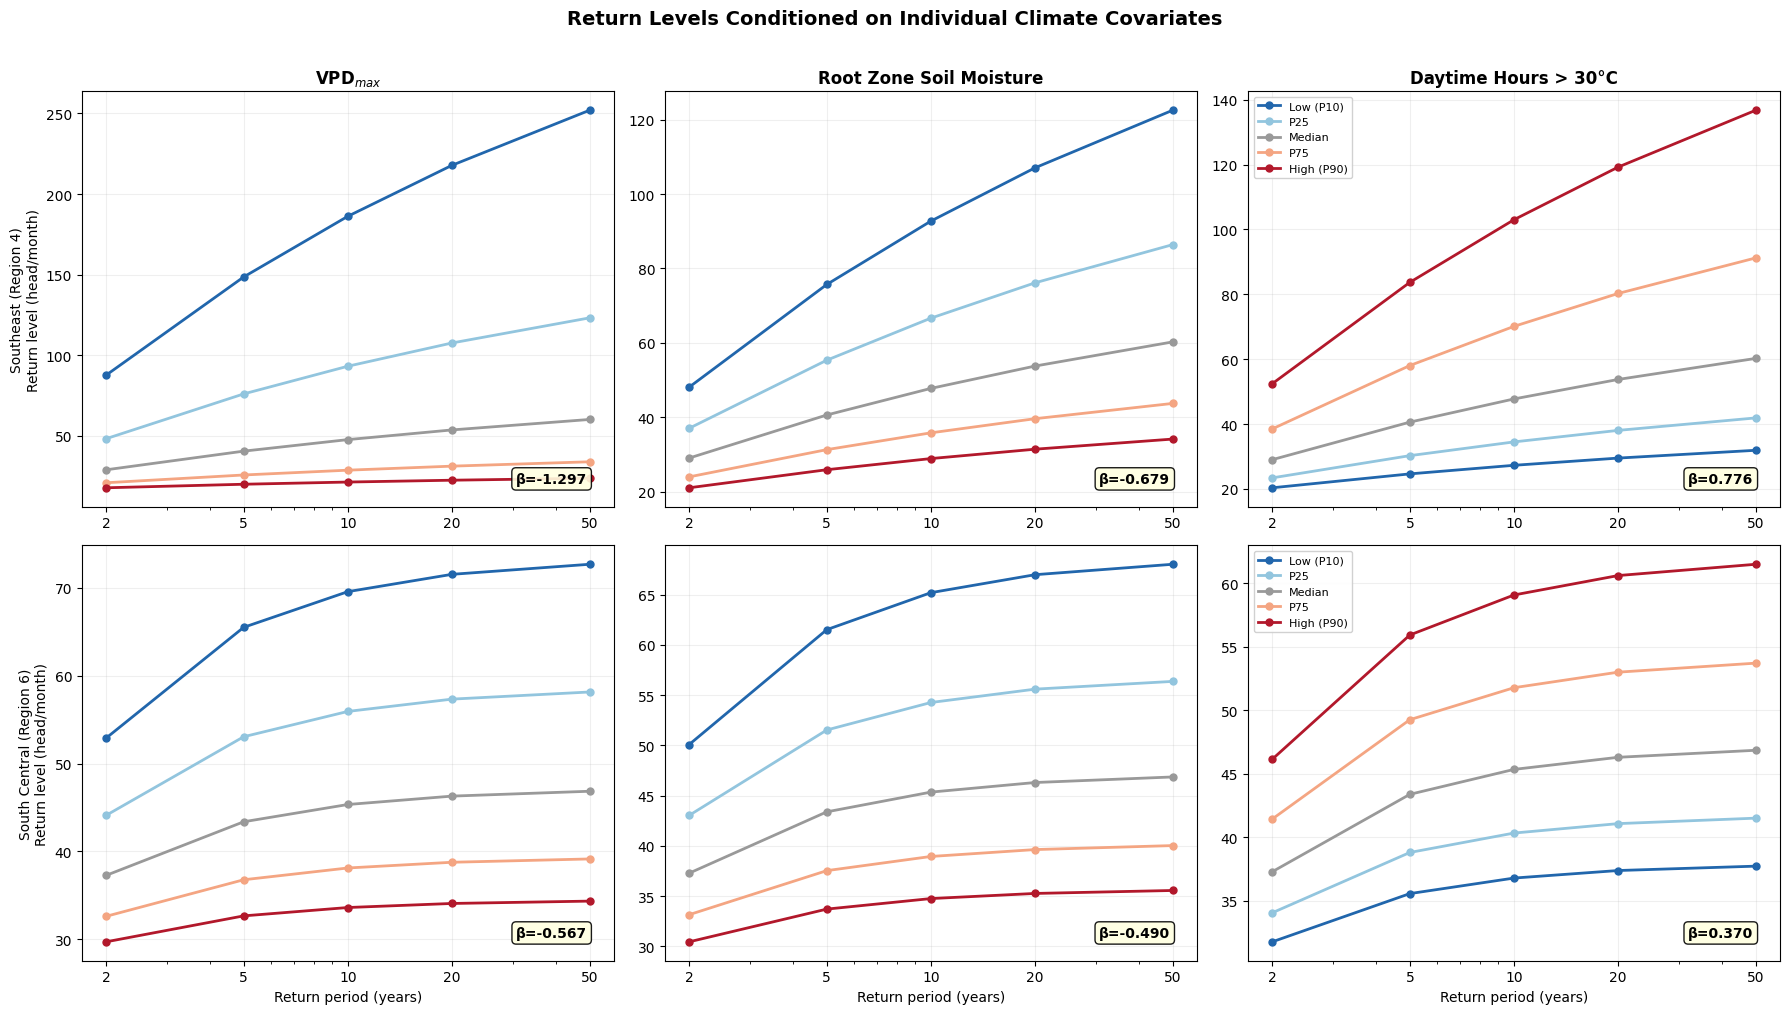

Saved: figures/paper/evt_conditioned_return_levels.png

Note: beta > 0 means higher covariate value -> larger scale -> more extreme events
      beta < 0 means higher covariate value -> smaller scale -> less extreme events


In [49]:
# ============================================================
# Figure 4: Return levels conditioned on each climate covariate
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

return_periods = np.array([2, 5, 10, 20, 50])

# One column per covariate, one row per region
covariate_labels = {
    "mean_vpd_max": "VPD$_{max}$",
    "mean_rzmc": "Root Zone Soil Moisture",
    "mean_daytime_hours_above_30": "Daytime Hours > 30\u00b0C",
}

scenario_configs = [
    ("Low (P10)", -1.28, "#2166AC"),
    ("P25", -0.675, "#92C5DE"),
    ("Median", 0.0, "#999999"),
    ("P75", 0.675, "#F4A582"),
    ("High (P90)", 1.28, "#B2182B"),
]

for row, region in enumerate(["region_4", "region_6"]):
    region_name = config.REGION_DISPLAY_NAMES.get(region, region)

    if region not in evt_results:
        for col in range(3):
            axes[row, col].text(0.5, 0.5, "No EVT results",
                                transform=axes[row, col].transAxes, ha="center")
        continue

    r = evt_results[region]
    region_train = df_train[df_train["region"] == region].copy()

    anomalies = region_train["slaughter_anomaly"].values
    threshold = np.percentile(anomalies, THRESHOLD_QUANTILE * 100)
    exceed_mask = anomalies > threshold
    exceedances = anomalies[exceed_mask] - threshold
    n_total = len(anomalies)
    n_exceed = len(exceedances)
    exceed_rate = n_exceed / n_total

    xi = r["nonstationary"]["shape"]
    betas = r["nonstationary"]["betas"]
    feat_names = r["feature_names"]

    for col, feat in enumerate(feat_names):
        ax = axes[row, col]

        for label, z_val, color in scenario_configs:
            # Vary only this covariate, hold others at mean (z=0)
            x_scenario = np.zeros(len(feat_names))
            x_scenario[col] = z_val

            # For RZMC, flip sign interpretation:
            # positive z = more moisture = LESS stress
            # So "High (P90)" RZMC = wet = low stress

            log_sigma = betas[0] + x_scenario @ betas[1:]
            sigma = np.exp(log_sigma)

            return_levels = []
            for T in return_periods:
                T_months = T * 12
                if xi != 0:
                    z_T = threshold + (sigma / xi) * ((T_months * exceed_rate)**xi - 1)
                else:
                    z_T = threshold + sigma * np.log(T_months * exceed_rate)
                return_levels.append(z_T)

            ax.plot(return_periods, return_levels, "o-", color=color,
                    linewidth=2, markersize=5, label=label)

        ax.set_xscale("log")
        ax.set_xticks(return_periods)
        ax.set_xticklabels([str(t) for t in return_periods])
        ax.grid(True, alpha=0.2)

        if row == 0:
            ax.set_title(covariate_labels.get(feat, feat), fontsize=12, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{region_name}\nReturn level (head/month)", fontsize=10)
        if row == 1:
            ax.set_xlabel("Return period (years)", fontsize=10)
        if col == 2:
            ax.legend(fontsize=8, loc="upper left", framealpha=0.9)

        # Show beta coefficient
        beta_val = betas[col + 1]  # +1 for intercept
        ax.text(0.95, 0.05, f"\u03b2={beta_val:.3f}",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))

fig.suptitle("Return Levels Conditioned on Individual Climate Covariates",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(config.PAPER_FIGURES_DIR / "evt_conditioned_return_levels.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figures/paper/evt_conditioned_return_levels.png")
print("\nNote: beta > 0 means higher covariate value -> larger scale -> more extreme events")
print("      beta < 0 means higher covariate value -> smaller scale -> less extreme events")

/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/447661720.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_boxes, labels=labels_boxes, patch_artist=True,
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/447661720.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_boxes, labels=labels_boxes, patch_artist=True,
/var/folders/jq/m05tkv2d1llbn0w9wc6cltyr0000gn/T/ipykernel_70139/447661720.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_boxes, labels=labels_boxes, patch_artist=True,


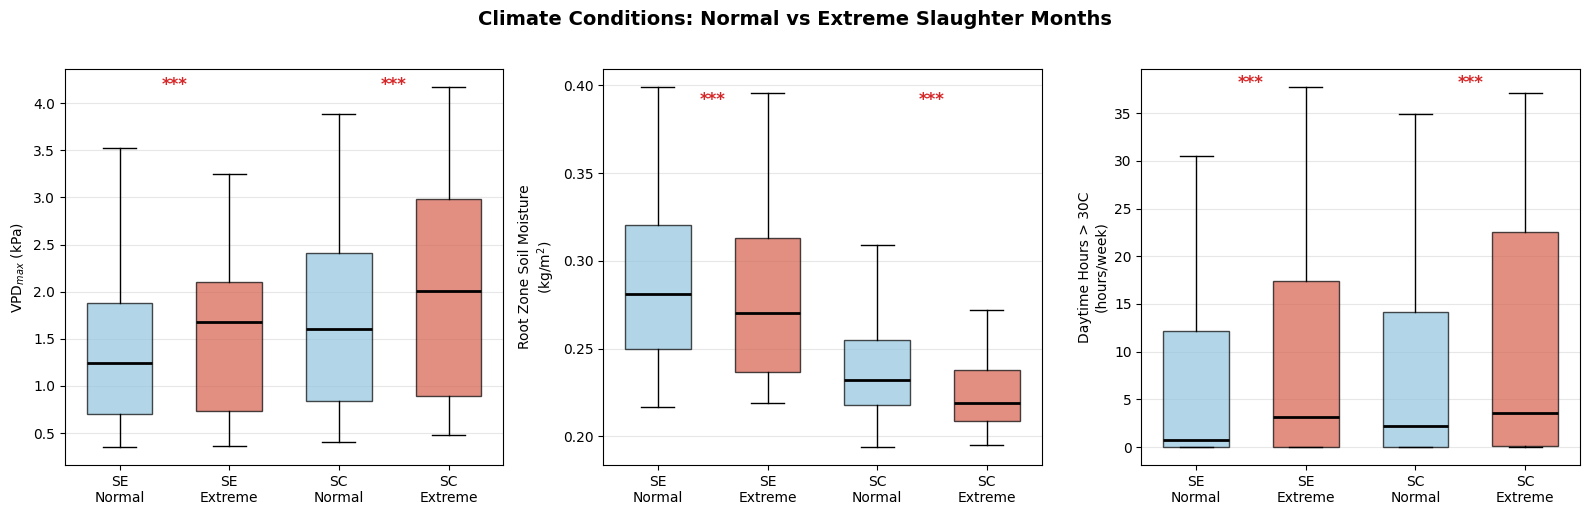

Saved: figures/paper/extreme_vs_normal_climate.png

*** = p<0.001, ** = p<0.01, * = p<0.05, ns = not significant (Mann-Whitney U)


In [50]:
# ============================================================
# Figure 5: Climate conditions during extreme vs normal months
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

compare_features = [
    ("mean_vpd_max", "VPD$_{max}$ (kPa)"),
    ("mean_rzmc", "Root Zone Soil Moisture\n(kg/m$^2$)"),
    ("mean_daytime_hours_above_30", "Daytime Hours > 30C\n(hours/week)"),
]

for ax, (feat, label) in zip(axes, compare_features):
    data_boxes = []
    labels_boxes = []
    box_colors = []

    for region in ["region_4", "region_6"]:
        region_train = df_train[df_train["region"] == region].copy()
        anomalies = region_train["slaughter_anomaly"].values
        threshold = np.percentile(anomalies, THRESHOLD_QUANTILE * 100)

        normal_vals = region_train.loc[anomalies <= threshold, feat].dropna()
        extreme_vals = region_train.loc[anomalies > threshold, feat].dropna()

        region_short = "SE" if region == "region_4" else "SC"
        data_boxes.extend([normal_vals, extreme_vals])
        labels_boxes.extend([f"{region_short}\nNormal", f"{region_short}\nExtreme"])
        box_colors.extend(["#92C5DE", "#D6604D"])

    bp = ax.boxplot(data_boxes, labels=labels_boxes, patch_artist=True,
                     widths=0.6, showfliers=False)

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, axis="y", alpha=0.3)

    # Statistical test (Mann-Whitney) for each region
    for i, region in enumerate(["region_4", "region_6"]):
        region_train = df_train[df_train["region"] == region]
        anomalies = region_train["slaughter_anomaly"].values
        threshold = np.percentile(anomalies, THRESHOLD_QUANTILE * 100)
        normal = region_train.loc[anomalies <= threshold, feat].dropna()
        extreme = region_train.loc[anomalies > threshold, feat].dropna()

        u_stat, u_pval = stats.mannwhitneyu(extreme, normal, alternative="two-sided")
        sig_str = "***" if u_pval < 0.001 else ("**" if u_pval < 0.01 else
                  ("*" if u_pval < 0.05 else "ns"))

        x_pos = 1.5 + i * 2
        y_pos = ax.get_ylim()[1] * 0.95
        ax.text(x_pos, y_pos, sig_str, ha="center", fontsize=12,
                fontweight="bold", color="#D62728" if u_pval < 0.05 else "gray")

fig.suptitle("Climate Conditions: Normal vs Extreme Slaughter Months",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(config.PAPER_FIGURES_DIR / "extreme_vs_normal_climate.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figures/paper/extreme_vs_normal_climate.png")
print("\n*** = p<0.001, ** = p<0.01, * = p<0.05, ns = not significant (Mann-Whitney U)")

## Phase 4: Synthesis

Summary of findings and paper narrative.


In [51]:
# Final synthesis
print("="*80)
print("MONTHLY ANOMALY PREDICTION -- KEY RESULTS")
print("="*80)

print(f"""
BASELINE MODELS:
  Climatology (y=0):     R2={r2_clim_test:.4f}, RMSE={rmse_clim_test:.2f}
  Ridge (climate only):  R2={r2_ridge_test:.4f}, RMSE={rmse_ridge_test:.2f}
  AR(1) monthly:         R2={r2_ar_pooled:.4f}, RMSE={np.sqrt(mean_squared_error(all_y_test_ar, all_y_pred_ar)):.2f}

EXTREME VALUE ANALYSIS (GPD):""")

for region in evt_results:
    r = evt_results[region]
    region_name = config.REGION_DISPLAY_NAMES.get(region, region)
    print(f"""
  {region_name}:
    Stationary GPD:     shape={r['stationary']['shape']:.4f}, scale={r['stationary']['scale']:.2f}
    Non-stationary GPD: shape={r['nonstationary']['shape']:.4f}
    Scale coefficients: {dict(zip(r['feature_names'], r['nonstationary']['betas'][1:]))}
    Likelihood Ratio:   stat={r['lr_test']['statistic']:.4f}, p={r['lr_test']['p_value']:.6f}
    AIC improvement:    {r['aic_stationary'] - r['aic_nonstationary']:.1f} (lower = better)""")

print(f"""
PAPER NARRATIVE:
  Temporal persistence dominates cattle slaughter at all timescales
  (monthly AR R2={r2_ar_pooled:.4f}, weekly AR R2=0.94).

  Climate does NOT predict mean slaughter anomalies
  (Ridge R2={r2_ridge_test:.4f}, Granger: 0 sig. features).

  However, climate SIGNIFICANTLY predicts EXTREME slaughter events
  (GPD LR test p<0.001 for both regions).

  This is consistent with a biological threshold model:
  heat stress triggers emergency herd liquidation only above
  critical physiological limits, producing extreme outliers
  rather than gradual shifts in average slaughter.

OTHER METHODS (archived in paper_05_archive_methods.ipynb):
  GAM: R2=0.035 (nonlinearity does not help)
  Granger: 0 significant features after BH correction
  GAMLSS: Heteroscedasticity in-sample but does not generalize
  Regime-switching: Converged but no additional insight
""")


MONTHLY ANOMALY PREDICTION -- KEY RESULTS

BASELINE MODELS:
  Climatology (y=0):     R2=-0.0228, RMSE=20.00
  Ridge (climate only):  R2=0.0421, RMSE=19.36
  AR(1) monthly:         R2=0.9482, RMSE=4.50

EXTREME VALUE ANALYSIS (GPD):

  Southeast (Region 4):
    Stationary GPD:     shape=-0.0788, scale=16.35
    Non-stationary GPD: shape=-0.2514
    Scale coefficients: {'mean_vpd_max': np.float64(-1.2973632165921378), 'mean_rzmc': np.float64(-0.6788684857617101), 'mean_daytime_hours_above_30': np.float64(0.7762496780821724)}
    Likelihood Ratio:   stat=87.4924, p=0.000000
    AIC improvement:    81.5 (lower = better)

  South Central (Region 6):
    Stationary GPD:     shape=-0.2321, scale=12.97
    Non-stationary GPD: shape=-1.0421
    Scale coefficients: {'mean_vpd_max': np.float64(-0.566913161422923), 'mean_rzmc': np.float64(-0.49049873490859935), 'mean_daytime_hours_above_30': np.float64(0.3696844650369656)}
    Likelihood Ratio:   stat=148.3410, p=0.000000
    AIC improvement:    1